In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")

df.head()

df["sex"] = df["sex"].map({
    "female": 0,
    "male": 1
})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [4]:
df["smoker"] = df["smoker"].map({
    "yes" : 1,
    "no" : 0
})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [5]:
df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [6]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [7]:
corr = df.corr()
print(corr)

                       age       sex       bmi  children    smoker   charges  \
age               1.000000 -0.020856  0.109272  0.042469 -0.025019  0.299008   
sex              -0.020856  1.000000  0.046371  0.017163  0.076185  0.057292   
bmi               0.109272  0.046371  1.000000  0.012759  0.003750  0.198341   
children          0.042469  0.017163  0.012759  1.000000  0.007673  0.067998   
smoker           -0.025019  0.076185  0.003750  0.007673  1.000000  0.787251   
charges           0.299008  0.057292  0.198341  0.067998  0.787251  1.000000   
region_northwest -0.000407 -0.011156 -0.135996  0.024806 -0.036945 -0.039905   
region_southeast -0.011642  0.017117  0.270025 -0.023066  0.068498  0.073982   
region_southwest  0.010016 -0.004184 -0.006205  0.021914 -0.036945 -0.043210   

                  region_northwest  region_southeast  region_southwest  
age                      -0.000407         -0.011642          0.010016  
sex                      -0.011156          0.017117 

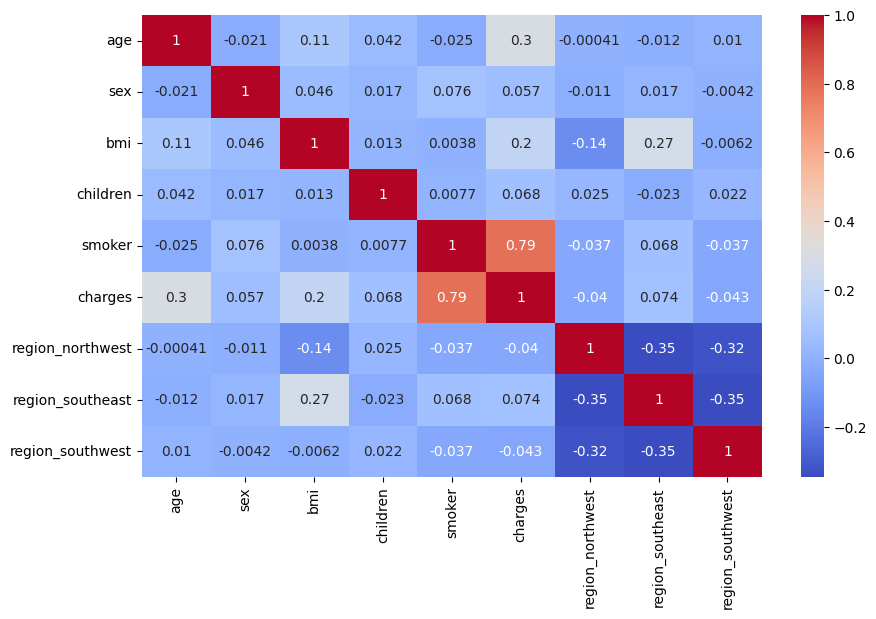

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap = "coolwarm")
plt.show()

**based on heatmap we only use strong correlations like smoker,age and bmi**

In [9]:
df = df.drop(["region_northwest", "region_southeast", "region_southwest"],axis=1)

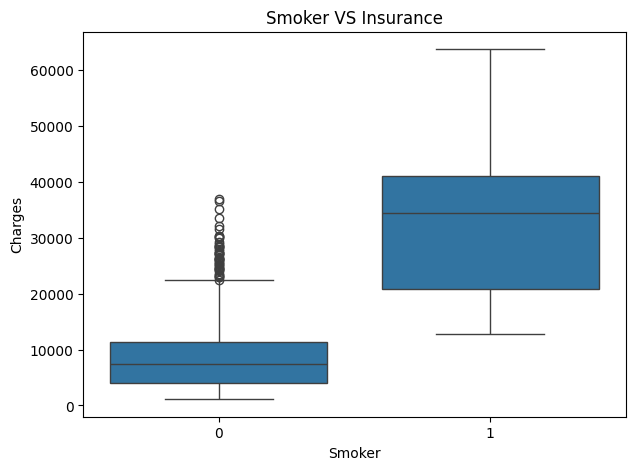

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="smoker",y="charges")
plt.title("Smoker VS Insurance")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

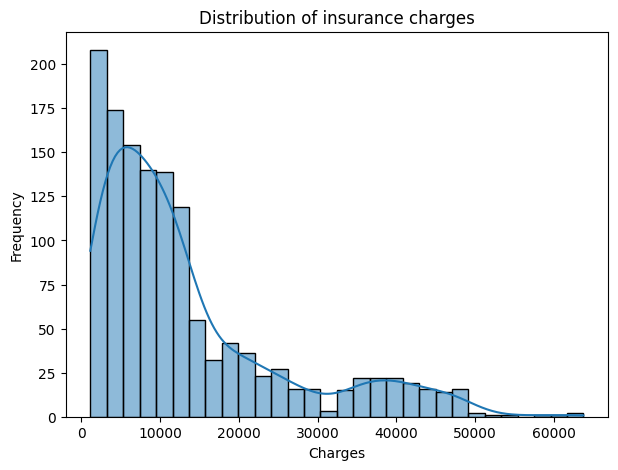

In [11]:
plt.figure(figsize=(7,5))
sns.histplot(df["charges"],kde=True)
plt.title("Distribution of insurance charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

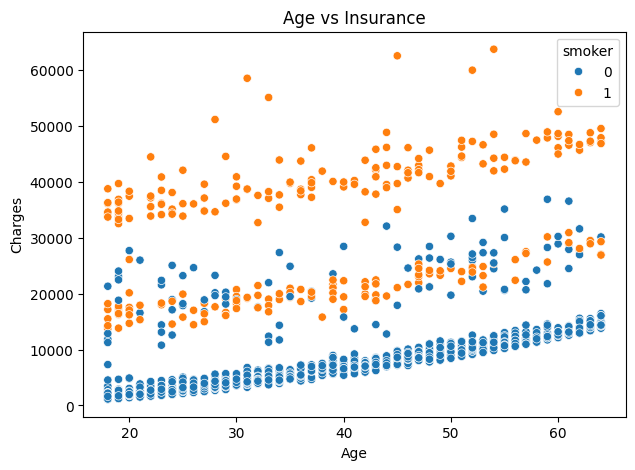

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x="age",y="charges",hue="smoker")
plt.title("Age vs Insurance")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

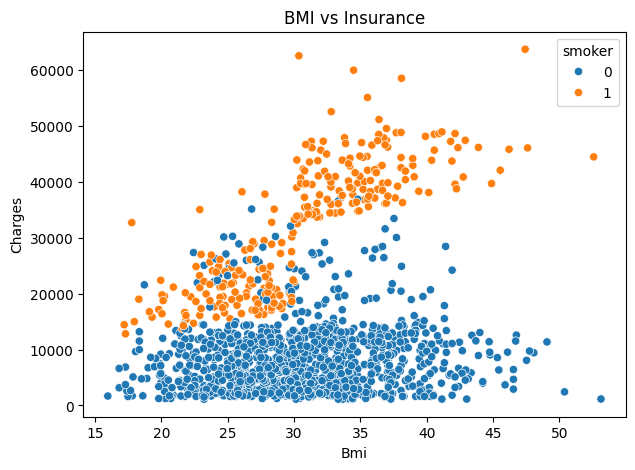

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x="bmi",y="charges",hue="smoker")
plt.title("BMI vs Insurance")
plt.xlabel("Bmi")
plt.ylabel("Charges")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


df["s_bmi"] = df["smoker"] * df["bmi"]
df["s_age"] = df["smoker"] * df["age"]


X = df[["age","bmi","smoker","children","s_bmi","s_age"]]
y = df["charges"]
print(X.head())
print(y.head())

   age     bmi  smoker  children  s_bmi  s_age
0   19  27.900       1         0   27.9     19
1   18  33.770       0         1    0.0      0
2   28  33.000       0         3    0.0      0
3   33  22.705       0         0    0.0      0
4   32  28.880       0         0    0.0      0
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [16]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("R2 score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

R2 score: 0.8628216861546324
MSE: 21296759.212673713
RMSE: 4614.841190406633
MAE: 2785.1090466754795


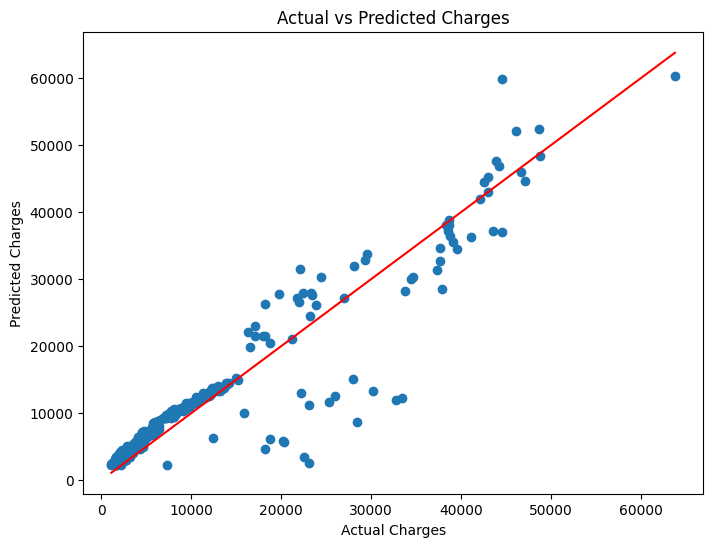

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()